## Problem Assignment: Numerical Schemes for the 1D Linear Advection Equation

### 1\. Problem Definition

You are tasked with numerically solving the 1D linear advection equation:

$$
\frac{\partial u}{\partial t} + \frac{\partial u}{\partial x} = 0
$$

This equation describes a wave $u(x, t)$ traveling to the right with a constant speed $c=1$.

* **Domain:** A periodic spatial domain, $x \in [0, 25.0]$.
* **Initial Condition ($t=0$):** The solution starts as a sum of two pulses:
$u(x, 0) = \exp(-20.0(x - 2)^2) + \exp(-(x - 5)^2)$
* **Exact Solution:** For this problem, the exact solution is the initial shape simply "advecting" or moving to the right. It is given by $u(x, t) = u(x-t, 0)$.

We will use the following Python function to represent the exact solution at any given time `t`:

```python
import numpy as np
u_true = lambda x, t: np.exp(-20.0 * ((x - t) - 2.0)**2) + np.exp(-((x - t) - 5.0)**2)
```

-----


### 2\. Numerical Setup

All your simulations must use the following discretization parameters:

* **Grid Points:** `m = 501`
* **Spatial Grid:** `x = np.linspace(0, 25.0, m)`
* **Grid Spacing:** $\Delta x = 25.0 / (m - 1)$
* **Final Time:** `t_final = 17.0`
* **CFL Number:** $\nu = 0.8$ (Note: $\nu = c \frac{\Delta t}{\Delta x}$, and since $c=1$, $\nu = \frac{\Delta t}{\Delta x}$)
* **Time Step:** $\Delta t = \nu \cdot \Delta x$

-----



### 3\. Your Task: Implement and Compare

Your main task is to implement **five** different finite difference schemes to solve this problem. For each scheme, you will write a time-stepping loop that starts with the initial condition `U = u_true(x, 0)` and runs until `t = t_final`.

**Crucial:** You must correctly implement the **periodic boundary conditions** for each scheme. This means that for a grid point $U_i$, its right neighbor $U_{i+1}$ and left neighbor $U_{i-1}$ must "wrap around" at the boundaries.

* For $i=0$ (the first point), the left neighbor is $U_{m-1}$ (the last point).
* For $i=m-1$ (the last point), the right neighbor is $U_0$ (the first point).

Implement the following five methods (where $\nu = \Delta t / \Delta x$):

1.  **FTCS (Forward-Euler, Central-Space):**
2.  **Lax-Friedrichs:**
3.  **Upwind (First-Order):**
4.  **Lax-Wendroff:**
5.  **Beam-Warming:**

-----



### 4\. Deliverables

You will submit your Jupyter Notebook as a pdf that completes the following:

1.  **Code:** A single script containing:

      * The setup (imports, parameters, initial condition).
      * A separate simulation loop for **each of the five methods**.
      * Store the final solution `U` from each method in a clearly named variable (e.g., `U_fe`, `U_lax_friedrichs`, etc.).

2.  **Plot:** A single, clear plot that visualizes the results at $t=17.0$. The plot must include:

      * The **exact solution** `u_true(x, t_final)` plotted as a solid black line (`'k'`).
      * The numerical results from **all five methods**. Plot each with a different style (e.g., `'ro'`, `'b--'`, `'g.'`, etc.) so they are distinguishable.
      * A clear **legend** identifying which line/marker corresponds to which method.
      * The plot limits set to zoom in on the solution:
          * `axes.set_xlim((15.0, 25.0))`
          * `axes.set_ylim((-0.1, 1.1))`

3.  **Analysis (Written):** In comments in your script or in a notebook markdown cell, answer the following questions:

      * **Stability:** Which (if any) methods failed to produce a stable solution? Based on what you know about numerical methods, why was this expected?
      * **Diffusion & Dispersion:** Compare the "good" solutions to the exact solution.
          * Which methods appear overly **diffusive** (smeared out)?
          * Which methods exhibit **dispersion** (spurious oscillations or "wiggles") near the sharp pulses?
      * **Conclusion:** Briefly state which method you think performed best and why.

-----


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Setup
u_true = lambda x, t: np.exp(-20.0 * ((x - t) - 2.0)**2) + np.exp(-((x - t) - 5.0)**2)

m = 501
x = np.linspace(0.0, 25.0, m)
delta_x = 25.0 / (m - 1)
cfl = 0.8
delta_t = cfl * delta_x
t_final = 17.0

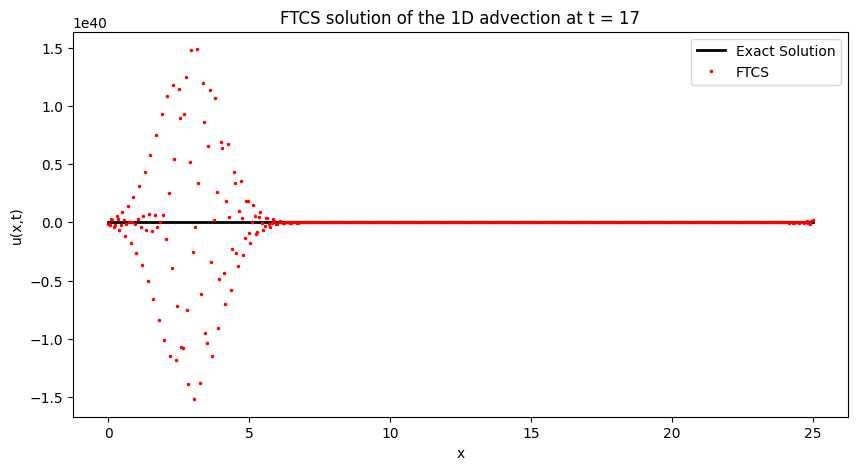

In [ ]:
#FTCS (Forward-Euler, Central-Space)
U_fe = u_true(x, 0).copy()
U_new = np.empty(U_fe.shape)
t = 0

while t < t_final:
    dt = min(delta_t, t_final - t)
    nu = dt / delta_x

    for i in range(m):
        if i == 0:
            left = U_fe[-1]
            right = U_fe[i+1]
        elif i == m-1:
            left = U_fe[i-1]
            right = U_fe[0]
        else:
            left = U_fe[i-1]
            right = U_fe[i+1]

        U_new[i] = U_fe[i] - 0.5 * nu * (right - left)

    U_fe[:] = U_new
    t += dt

plt.figure(figsize=(10,5))
plt.plot(x, u_true(x, t_final), 'k', linewidth=2, label='Exact Solution')
plt.plot(x, U_fe, 'r.', markersize=3, label='FTCS')
plt.xlim()
plt.ylim()
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('FTCS solution of the 1D advection at t = 17')
plt.legend()
plt.show()


In [ ]:
# Lax-Friedrichs
U_lax_friedrichs = u_true(x, 0).copy()
U_new = np.empty(U_fe.shape)
t=0

while t < t_final:
    dt = min(delta_t, t_final - t)
    nu = dt / delta_x

    for i in range(m):
        if i == 0:
            left = U_lax_friedrichs[-1]
            right = U_lax_friedrichs[i+1]
        elif i == m-1:
            left = U_lax_friedrichs[i-1]
            right = U_lax_friedrichs[0]
        else:
            left = U_lax_friedrichs[i-1]
            right = U_lax_friedrichs[i+1]

        U_new[i] = 0.5 * (left + right) - 0.5 * nu * (right - left)

    U_lax_friedrichs[:] = U_new
    t += dt


In [ ]:
#Upwind
U_upwind = u_true(x, 0).copy()
U_new = np.empty(U_upwind.shape)
t=0

while t < t_final:
    dt = min(delta_t, t_final - t)
    nu = dt / delta_x

    for i in range(len(U_upwind)):
        if i == 0:
            left = U_upwind[-1]
        else:
            left = U_upwind[i-1]

        U_new[i] = U_upwind[i] - nu * (U_upwind[i] - left)

    U_upwind[:] = U_new
    t += dt

In [ ]:
#Lax-Wendroff
U_lax_wendroff = u_true(x, 0).copy()
U_new = np.empty(U_lax_wendroff.shape)
t=0

while t < t_final:
    dt = min(delta_t, t_final - t)
    nu = dt / delta_x

    for i in range(len(U_lax_wendroff)):
        left  = U_lax_wendroff[i-1] if i > 0 else U_lax_wendroff[-1]
        right = U_lax_wendroff[i+1] if i < len(U_lax_wendroff)-1 else U_lax_wendroff[0]

        U_new[i] = (U_lax_wendroff[i]
                    - 0.5 * nu * (right - left)
                    + 0.5 * nu**2 * (right - 2*U_lax_wendroff[i] + left))

    U_lax_wendroff[:] = U_new
    t += dt


In [ ]:
#Beam-Warming
U_beam_warming = u_true(x, 0).copy()
U_new = np.empty(U_beam_warming.shape)
t=0

while t < t_final:
    dt = min(delta_t, t_final - t)
    nu = dt / delta_x

    for i in range(len(U_beam_warming)):
        U_i   = U_beam_warming[i]
        U_im1 = U_beam_warming[i-1] if i > 0 else U_beam_warming[-1]
        U_im2 = U_beam_warming[i-2] if i > 1 else U_beam_warming[-2 + i]

        U_new[i] = (U_i
                    - 0.5 * nu * (3*U_i - 4*U_im1 + U_im2)
                    + 0.5 * nu**2 * (U_i - 2*U_im1 + U_im2))

    U_beam_warming[:] = U_new
    t += dt

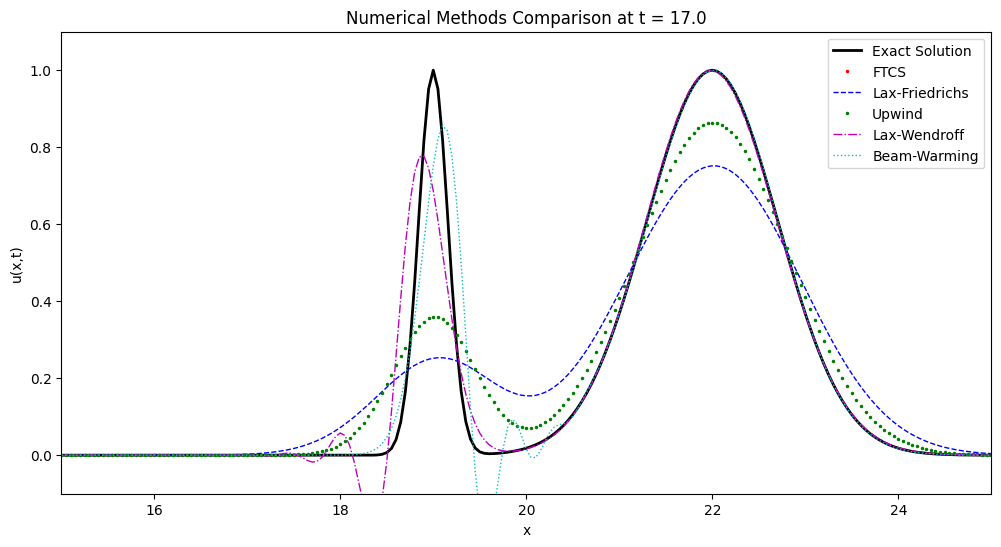

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(figsize=(12,6))

axes.plot(x, u_true(x, t_final), 'k', linewidth=2, label='Exact Solution')

axes.plot(x, U_fe, 'r.', markersize=3, label='FTCS')
axes.plot(x, U_lax_friedrichs, 'b--', linewidth=1, label='Lax-Friedrichs')
axes.plot(x, U_upwind, 'g.', markersize=3, label='Upwind')
axes.plot(x, U_lax_wendroff, 'm-.', linewidth=1, label='Lax-Wendroff')
axes.plot(x, U_beam_warming, 'c:', linewidth=1, label='Beam-Warming')

axes.set_xlim((15.0, 25.0))
axes.set_ylim((-0.1, 1.1))

axes.set_xlabel('x')
axes.set_ylabel('u(x,t)')
axes.set_title(f'Numerical Methods Comparison at t = {t_final}')
axes.legend()
plt.show()


**Stability and Accuracy of Numerical Methods**

FTCS (Forward-Time, Central-Space)
- Stability: Unstable => solution explodes quickly (up to 10^40 for long times).
- Diffusion: Not meaningful (diverges).
- Dispersion: Not meaningful.
- Remarks: FTCS is unconditionally unstable for pure advection; it was plotted separately because in the combined plot the solution was not visible due to extreme blow-up.

Lax-Friedrichs
- Stability: Stable for CFL ≤ 1.
- Diffusion: Highly diffusive => pulses smeared out.
- Dispersion: Minimal.
- Remarks: Smooths both sharp and wide pulses; stable but overly dissipative.

Upwind (1st order)
- Stability: Stable for CFL ≤ 1.
- Diffusion: Moderately diffusive => sharp pulses slightly flattened.
- Dispersion: Minimal.
- Remarks: Simple and stable; preserves wide pulses reasonably well, but not ideal for sharp gradients.

Lax-Wendroff (2nd order)
- Stability: Stable for CFL ≤ 1.
- Diffusion: Low => pulses remain sharp.
- Dispersion: Slight oscillations near steep pulses.
- Remarks: Good balance between accuracy and stability; handles both sharp and wide pulses well. The second, wider pulse is almost perfectly preserved.

Beam-Warming (2nd order, Upwind)
- Stability: Stable for CFL ≤ 1.
- Diffusion: Very low => sharp pulses preserved.
- Dispersion: Minor oscillations at very steep fronts.
- Remarks: Excellent for sharp pulses; slightly better than Lax-Wendroff for very steep gradients, but can show small wiggles. The second, wider pulse is also nearly perfectly preserved.

Overall Conclusion:
- Best-performing methods: Lax-Wendroff or Beam-Warming.
- Preserve pulse shape, minimal diffusion, stable.
- FTCS fails (blows up), Lax-Friedrichs too diffusive, Upwind moderately diffusive.


